In [32]:
# Decision Tree: Income Prediction

In [33]:
# Objective: To predict income using a dataset containing information on education level, training history, marital status, and occupation.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv('https://media.githubusercontent.com/media/musthave-ML10/data_source/main/salary.csv',\
                skipinitialspace = True)
#Source : https://media.githubusercontent.com/media/musthave-ML10
df.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [36]:
df['class'].unique()

array(['<=50K', '>50K'], dtype=object)

In [37]:
df.info()
#total : 48842 rows / 14 cols

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   education       48842 non-null  object
 3   education-num   48842 non-null  int64 
 4   marital-status  48842 non-null  object
 5   occupation      46033 non-null  object
 6   relationship    48842 non-null  object
 7   race            48842 non-null  object
 8   sex             48842 non-null  object
 9   capital-gain    48842 non-null  int64 
 10  capital-loss    48842 non-null  int64 
 11  hours-per-week  48842 non-null  int64 
 12  native-country  47985 non-null  object
 13  class           48842 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.2+ MB


In [9]:
# There are many categorical variables in the dataset, and a few variables were found to have missing values based on the non-null counts.

In [38]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,46043,8,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital-status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,46033,14,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital-gain,48842.0,NaN,NaN,NaN,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0


In [39]:
df['class'] = df['class'].map({'<=50K':0, '>50K':1})

In [40]:
for i in df.columns:
    print(i, df[i].dtype)

age int64
workclass object
education object
education-num int64
marital-status object
occupation object
relationship object
race object
sex object
capital-gain int64
capital-loss int64
hours-per-week int64
native-country object
class int64


In [41]:
obj = []
for i in df.columns:
    if df[i].dtype == 'object':
        obj.append(i)
obj

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country']

In [15]:
# We performed preprocessing to convert object-type variables with fewer than 10 unique values into dummy variables. For those with 10 or more unique values, we reviewed whether feature engineering was necessary,
# in order to avoid creating an excessive number of dummy variables.

In [42]:
for i in obj:
    if df[i].nunique() >= 10:
        print(i, df[i].nunique())

education 16
occupation 14
native-country 41


In [43]:
df['education'].value_counts()

,count
education,
HS-grad,15784
Some-college,10878
Bachelors,8025
Masters,2657
Assoc-voc,2061
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955


In [44]:
np.sort(df['education-num'].unique())

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16])

In [45]:
df[df['education-num'] == 1]['education'].unique()

array(['Preschool'], dtype=object)

In [46]:
for i in np.sort(df['education-num'].unique()):
    print(i, df[df['education-num'] == i]['education'].unique())

1 ['Preschool']
2 ['1st-4th']
3 ['5th-6th']
4 ['7th-8th']
5 ['9th']
6 ['10th']
7 ['11th']
8 ['12th']
9 ['HS-grad']
10 ['Some-college']
11 ['Assoc-voc']
12 ['Assoc-acdm']
13 ['Bachelors']
14 ['Masters']
15 ['Prof-school']
16 ['Doctorate']


In [47]:
df.drop('education', axis = 1, inplace = True)

In [48]:
df['occupation'].value_counts()

,count
occupation,
Prof-specialty,6172
Craft-repair,6112
Exec-managerial,6086
Adm-clerical,5611
Sales,5504
Other-service,4923
Machine-op-inspct,3022
Transport-moving,2355
Handlers-cleaners,2072


In [23]:
# Upon review, we concluded that no additional preprocessing was necessary and that these variables can be handled later through dummy variable encoding.

In [49]:
df['native-country'].value_counts()

,count
native-country,
United-States,43832
Mexico,951
Philippines,295
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155
India,151
Cuba,138


In [50]:
df

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
48838,40,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
48839,58,Private,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
48840,22,Private,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


In [52]:
df.groupby('native-country')['class'].mean().sort_values(ascending=False)

,class
native-country,
France,0.421053
India,0.410596
Taiwan,0.400000
Iran,0.372881
England,0.370079
Greece,0.367347
Japan,0.347826
Yugoslavia,0.347826
Canada,0.346154


In [55]:
group = df.groupby('native-country')['class'].mean()

In [56]:
group

,class
native-country,
Cambodia,0.321429
Canada,0.346154
China,0.295082
Columbia,0.047059
Cuba,0.246377
Dominican-Republic,0.048544
Ecuador,0.133333
El-Salvador,0.070968
England,0.370079


In [57]:
sample = pd.DataFrame({'var_1':[3,5,7], 'var_2':[2,4,6]}, index = ['a','b','c'])
sample.reset_index()

,index,var_1,var_2
0,a,3,2
1,b,5,4
2,c,7,6


In [58]:
group = group.reset_index()
group

,native-country,class
0,Cambodia,0.321429
1,Canada,0.346154
2,China,0.295082
3,Columbia,0.047059
4,Cuba,0.246377
5,Dominican-Republic,0.048544
6,Ecuador,0.133333
7,El-Salvador,0.070968
8,England,0.370079
9,France,0.421053


In [59]:
df = df.merge(group, on = 'native-country', how = 'left')

df

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class_x,class_y
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0,0.243977
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0,0.243977
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,0.243977
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1,0.243977
4,18,NaN,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0,0.243977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0,0.243977
48838,40,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1,0.243977
48839,58,Private,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0,0.243977
48840,22,Private,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0,0.243977


In [60]:
df.drop('native-country', axis = 1, inplace = True)
df = df.rename(columns = {'class_x': 'class', 'class_y':'native-country'})
df

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,class,native-country
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,0,0.243977
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,0,0.243977
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,1,0.243977
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,1,0.243977
4,18,NaN,10,Never-married,NaN,Own-child,White,Female,0,0,30,0,0.243977
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,0,0.243977
48838,40,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,1,0.243977
48839,58,Private,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,0,0.243977
48840,22,Private,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,0,0.243977


In [61]:
df.isna().mean()

,0
age,0.000000
workclass,0.057307
education-num,0.000000
marital-status,0.000000
occupation,0.057512
relationship,0.000000
race,0.000000
sex,0.000000
capital-gain,0.000000
capital-loss,0.000000


In [62]:
# Although replacing missing values with -99 may distort the data in linear models, we used this approach in this case because we plan to apply a tree-based model, which is less sensitive to such imputation.

In [63]:
df['native-country'] = df['native-country'].fillna(-99)

In [64]:
df['workclass'].value_counts()

,count
workclass,
Private,33906
Self-emp-not-inc,3862
Local-gov,3136
State-gov,1981
Self-emp-inc,1695
Federal-gov,1432
Without-pay,21
Never-worked,10


In [65]:
df['workclass'] = df['workclass'].fillna('Private')

In [67]:
df['occupation'] = df['occupation'].fillna('Unknown')

In [68]:
df = pd.get_dummies(df, drop_first = True)

In [ ]:
# Training set :

In [69]:
from sklearn.model_selection import train_test_split
xtr,xt,ytr,yt = train_test_split(df.drop('class', axis = 1), df['class'], test_size = 0.4, random_state = 100)

In [70]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(xtr, ytr)

pred = dt.predict(xt)

In [71]:
from sklearn.metrics import accuracy_score

accuracy_score(yt, pred)

0.8152735834570303

In [72]:
dt = DecisionTreeClassifier(max_depth = 7)
dt.fit(xtr, ytr)
train_pred = dt.predict(xtr)
test_pred = dt.predict(xt)
print(accuracy_score(ytr, train_pred))
print(accuracy_score(yt, test_pred))

0.8598532673605187
0.8544300557915749


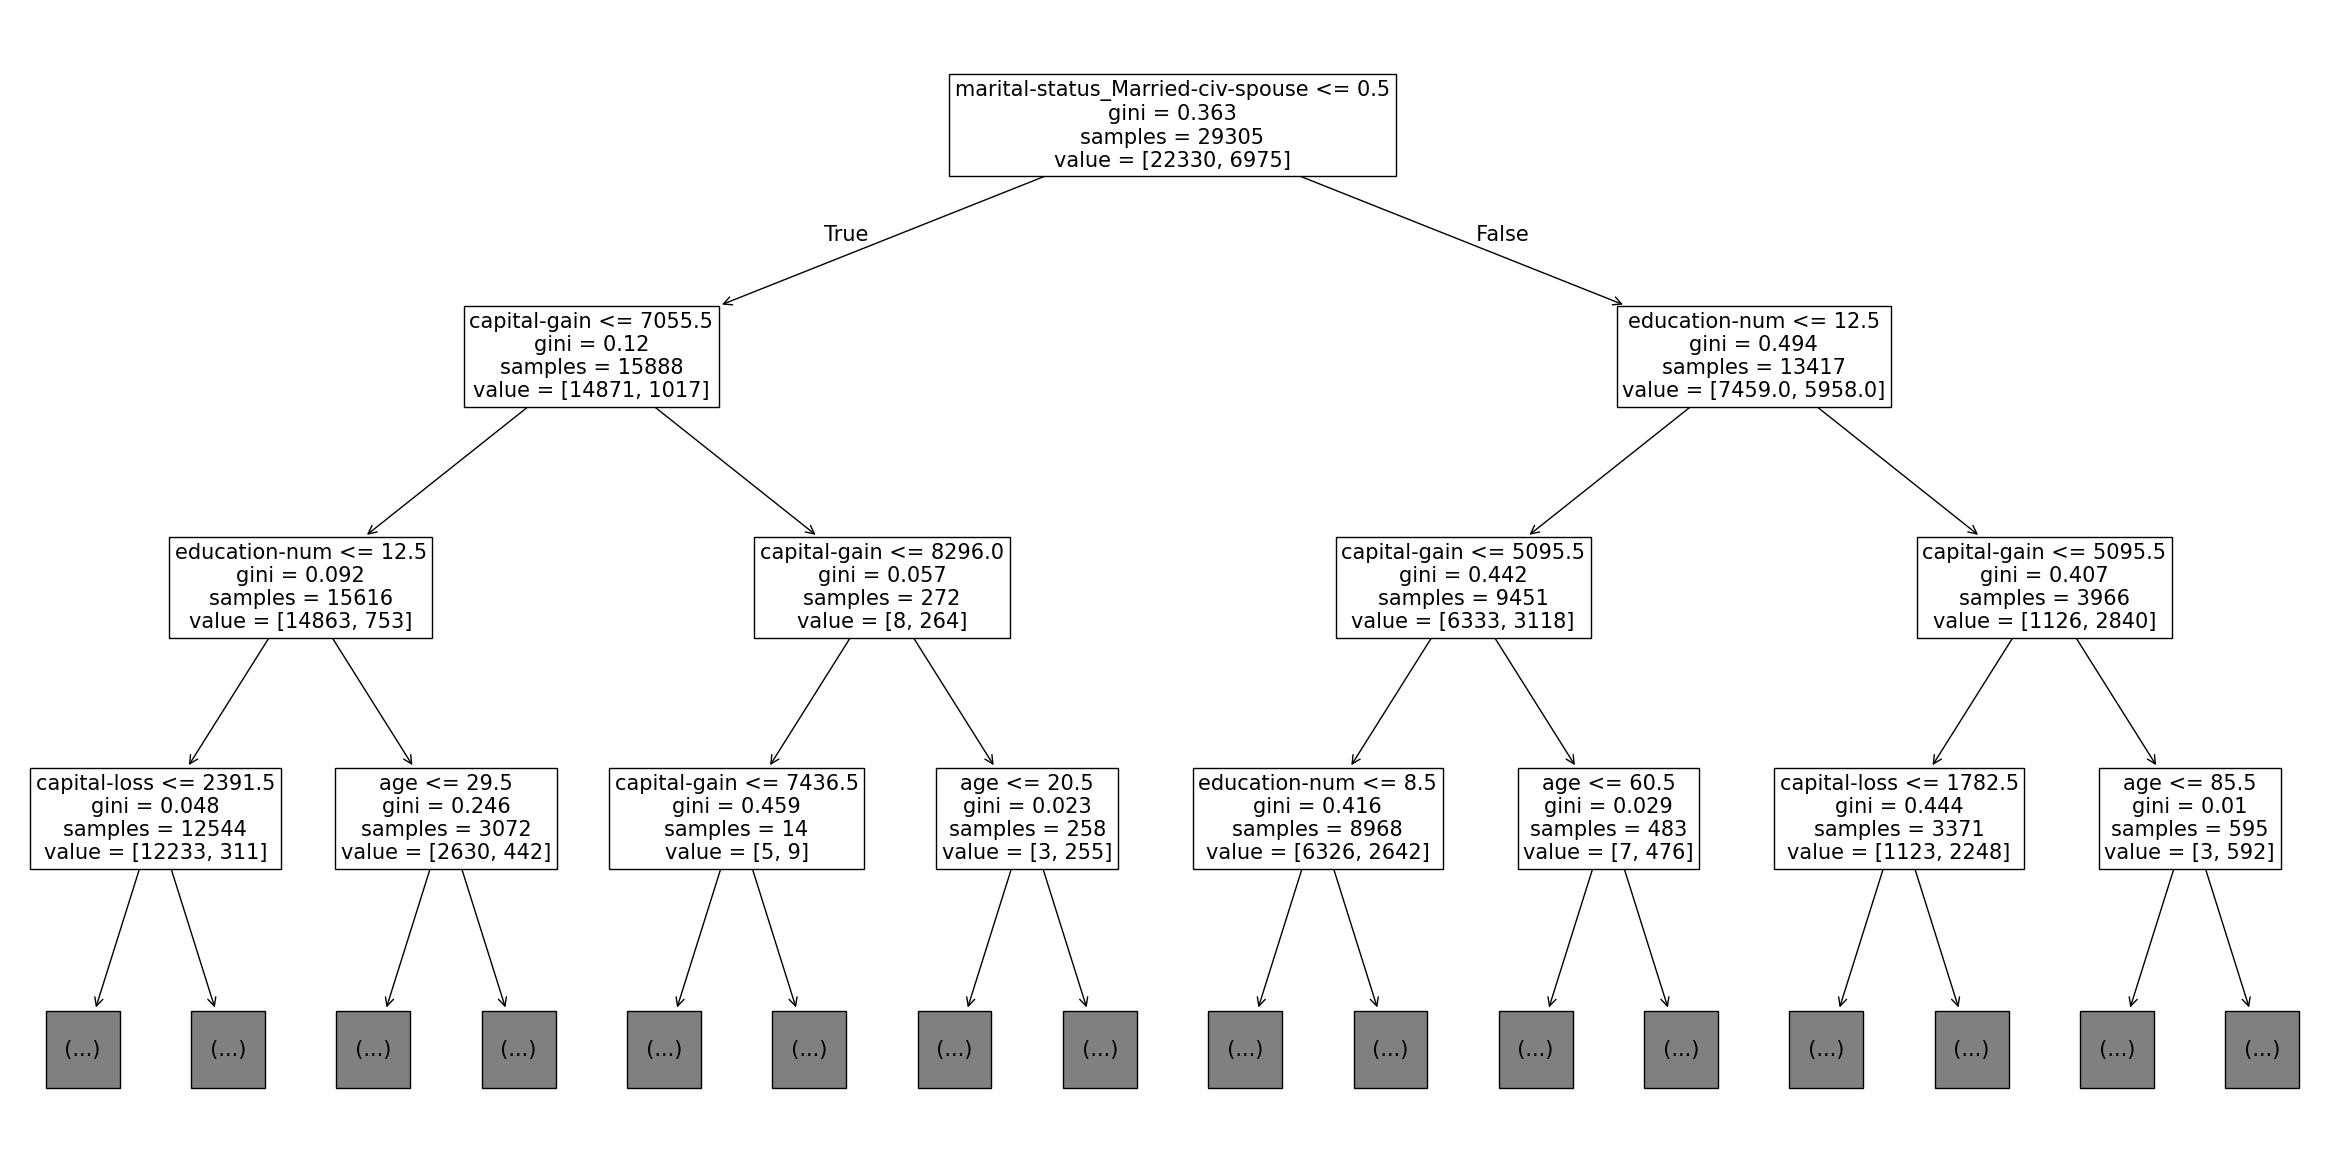

In [73]:
from sklearn.tree import plot_tree

plt.figure(figsize = (30,15))
plot_tree(dt, max_depth = 3, fontsize = 15, feature_names = xtr.columns)

plt.show()